<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>CROSS VAL SCORE FOR CLASSIFIER </h2>
</div>

## Module 14 Case study 1 - Cross val and Boosting

## Case Study

### Domain –Chemical Industry

### focus –Classify chemicalBusiness 

### challenge/requirement
- FuPont is a leading chemical company across the globe.  
- The Company is on a CSR (Corporate Social Responsibility) mission. 
- It wants to identify biodegradable products based on a study of the relationships between chemical structure and biodegradation of molecules. 
- You as ML expert have to create a ML model to classify the chemical structure as 
    'Ready BioDegradable' –RB vs 'Not Ready Biodegradable' –NRB

### Key issues:
    Data has lotsof attributes and classification could be tricky 

### Considerations
NONE

### Data volume-
    Approx 1055   records –file bio-degradabale-data.csv 
    Fields in Data
    •Details in .ipynb notebook 
    
### Additional information-NA

### Business benefits
- Research can lead FuPont to create truly unique Biodegradable packaging material. 
- This could lead to massive profits in future


<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>

##  1. Import all Librariy

In [20]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier

from sklearn import metrics

In [21]:
#Read data
df = pd.read_csv (r'..\Dataset\bio-degradabale-data.csv'
                 , sep=";" , header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
0,3.919,2.6909,0,0,0,0,0,31.4,2,0,...,0,0,0,2.949,1.591,0,7.253,0,0,RB
1,4.170,2.1144,0,0,0,0,0,30.8,1,1,...,0,0,0,3.315,1.967,0,7.257,0,0,RB
2,3.932,3.2512,0,0,0,0,0,26.7,2,4,...,0,0,1,3.076,2.417,0,7.601,0,0,RB
3,3.000,2.7098,0,0,0,0,0,20.0,0,2,...,0,0,1,3.046,5.000,0,6.690,0,0,RB
4,4.236,3.3944,0,0,0,0,0,29.4,2,4,...,0,0,0,3.351,2.405,0,8.003,0,0,RB


##  2. Data Wrangling

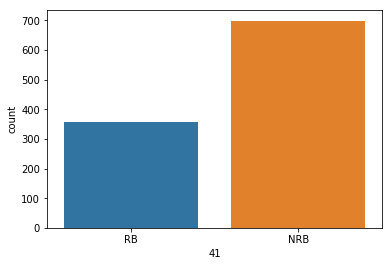

In [22]:
#DATA WRANGLING
import seaborn as sn
Y= df.iloc[:,-1]
sn.countplot(Y)
#Y

> Most of the data are NRB Non Rycycle type data

### 2.1 Data looks like continous I/P with 2 type O/P RB/NRB
- We will convert o/p to 0 0r 1 by label encoder
- Then will split the data
- use Logistinc Regression and RF (Classification) with KFOLD =10 and check the accuracy by cross validation, to see the best accuracy

In [31]:
from sklearn.model_selection import train_test_split

X = df.iloc[:,0:-1]
Y= df.iloc[:,-1]

# Here test_size= 5 restricts test set to only 5 rows
train_X, test_X,train_Y,test_Y = train_test_split(X,Y, random_state=5
                                               #   , test_size=5
                                                 )

In [32]:
print(test_X.shape)

(264, 41)


In [33]:
print(train_X.shape)

(791, 41)


In [34]:
# Label encoder

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(Y)
#le.classes_ provides distinct labels
print(le.classes_)
#array(['NRB', 'RB'], dtype=object)
# 0 -->NRB,  1--->RB
Y = le.transform(Y)

['NRB' 'RB']


## 3 Apply Logistic Regression with cross_val_score with cv = 10 fold

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

log_reg = LogisticRegression()

## Apply Cross validation on knn model, with k-fold/cv=10, and take mean which is the avg of all 10 accuracy
print("Logistic Regression accuracy is: \n")
print(cross_val_score(log_reg, train_X, train_Y, cv=10, scoring ='accuracy').mean())

Logistic Regression accuracy is: 

0.8585090068159689


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence t

In [36]:
log_reg.fit(train_X, train_Y)
pred_log_Y = log_reg.predict(test_X)

C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


In [37]:
from sklearn.metrics import confusion_matrix
confusion_matrix(test_Y, pred_log_Y)

array([[161,  19],
       [ 13,  71]], dtype=int64)


## 3. Apply Random Forest with cross_val_score with cv = 10 fold

In [38]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)

## Apply Cross validation on knn model, with k-fold/cv=10, and take mean which is the avg of all 10 accuracy
print("Random forest accuracy is: \n")
print(cross_val_score(rf, train_X, train_Y, cv=10, scoring ='accuracy').mean())

Random forest accuracy is: 

0.8419725738396625


In [39]:
rf.fit(train_X, train_Y)
pred_rf_Y = rf.predict(test_X)

confusion_matrix(test_Y, pred_rf_Y)

array([[166,  14],
       [ 19,  65]], dtype=int64)

## 4. Conclusion:

- By LR and RF, both gave same accuracy almost. so we can use any of this